In [ ]:
%%capture
%load_ext autoreload
%autoreload 2
%reset -f

In [ ]:
import jax
import numpy as np
import optax
from jax import numpy as jnp
from jax.numpy.fft import irfft, rfft, rfftfreq
from matplotlib import pyplot as plt

from otf import optim
from otf import time_integration as ti
from otf.asyncd import utils
from otf.system import System_LinearNonlinear_ModelKnown
from otf.system import (
    utils as system_utils,
)
from otf.time_integration.linear_nonlinear import ETD1, ETD2

from plot import plot

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

jndarray = jnp.ndarray

In [ ]:
def get_initial_values(x0: float, xf: float, n: int):
    """Get initial values for the true and nudged states.

    Parameters
    ----------
    x0, xf
        Endpoints of domain
    n
        Number of spatial grid points on [x0, xf]

    Returns
    -------
    u0
        Initial true state
    un0
        Initial nudged state
    """
    # Initial true state
    u = lambda x: 0.03 * np.sin(x)
    xls = jnp.linspace(x0, xf, n, endpoint=False)
    u0 = u(xls)

    # Initial simulation state
    un0 = jnp.zeros_like(u0)

    return rfft(u0), rfft(un0)

In [ ]:
def compute_spatial_derivative_factors_fourier(m: int, k: jndarray) -> jndarray:
    return (2 * jnp.pi * 1j * k) ** m


def compute_spatial_derivative_fourier(
    s: jndarray, m: int, k: jndarray
) -> jndarray:
    return (2 * jnp.pi * 1j * k) ** m * s


df = compute_spatial_derivative_fourier
dff = compute_spatial_derivative_factors_fourier

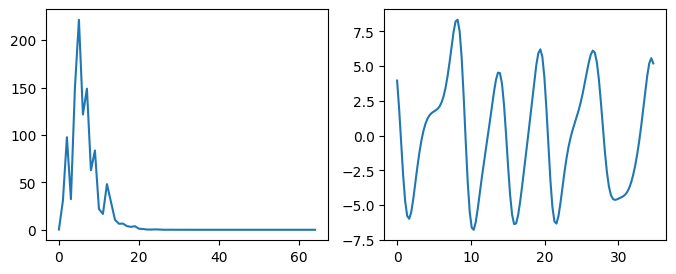

In [ ]:
def true_linear(gs: jndarray, k: jndarray) -> jndarray:
    g1, g2, g3 = gs

    return -(g1 * dff(2, k) + g3 * dff(4, k))


def true_nonlinear(gs: jndarray, true: jndarray, k: jndarray) -> jndarray:
    g1, g2, g3 = gs
    s = true

    return -g2 * rfft(irfft(s) * irfft(df(s, 1, k)))


def assimilated_linear(cs: jndarray, k: jndarray) -> jndarray:
    c1, c2, c3 = cs

    return -(c1 * dff(2, k) + c3 * dff(4, k))


def assimilated_nonlinear(
    cs: jndarray, assimilated: jndarray, k: jndarray
) -> jndarray:
    c1, c2, c3 = cs
    s = assimilated

    return -c2 * rfft(irfft(s) * irfft(df(s, 1, k)))


# System evolution parameters
gs = jnp.array([2, 1, 1], dtype=float)
cs = gs
mu = 25
x0, xf = 0, 35
xn = 128
k = rfftfreq(xn, (xf - x0) / xn)

true0, assimilated0 = get_initial_values(x0, xf, xn)

observed_slice = jnp.s_[:]
observed_mask = system_utils.mask_from_slice(observed_slice, true0.shape)
system = System_LinearNonlinear_ModelKnown(
    mu,
    gs,
    cs,
    observed_mask,
    lambda cs: assimilated_linear(cs, k),
    lambda cs, a: assimilated_nonlinear(cs, a, k),
    lambda gs: true_linear(gs, k),
    lambda gs, t: true_nonlinear(gs, t, k),
    complex_differentiation=True,
)

solver = ETD1(system)
solver = ETD2(system, solver)

# Simulation parameters
dt = 0.01
T0, Tf = 0, 600
t_relax = 1

gradient_computer = optim.gradient.AdjointGradient(
    system,
    optim.gradient.adjoint.UpdateOption.asymptotic,
    (ti.ForwardEuler, ti.TwoStepAdamsBashforth),
    dt,
)
optimizer = optax.adam(1e-2)
optimizer = optim.OptaxWrapper(system, optimizer, gradient_computer)

true, tls_ = solver.solve_true(true0, T0, Tf, dt)
true_observed = true[:, observed_mask]

i = -1
fig, axs = plt.subplots(1, 2, figsize=(8, 3))
axs[0].plot(abs(true[i]))
axs[1].plot(jnp.linspace(x0, xf, xn, endpoint=False), irfft(true[i]))
plt.show()

In [ ]:
return_all = True
cs, u_errors, tls, assimilated = utils.run_update(
    system,
    true_observed,
    solver,
    dt,
    T0,
    Tf,
    t_relax,
    assimilated0.ravel(),
    optimizer,
    return_all=return_all,
)

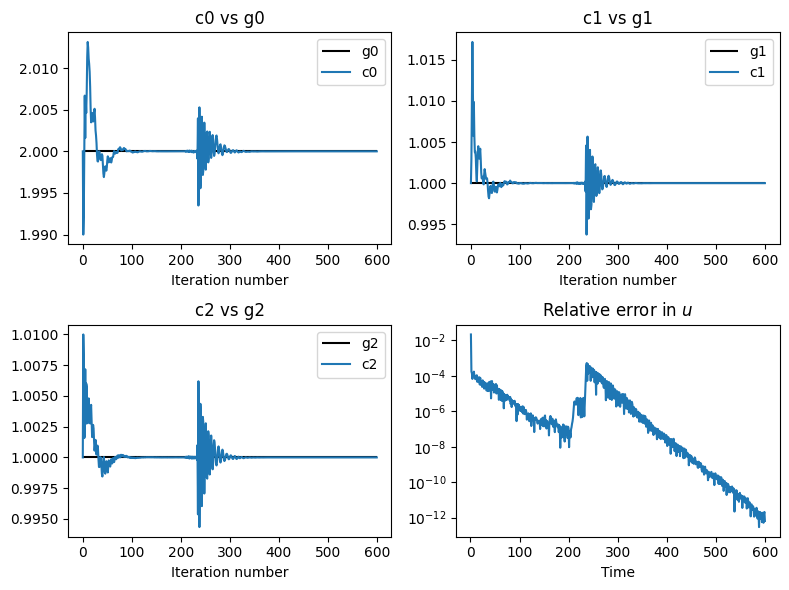

In [ ]:
fig, axs = plot(cs, u_errors, gs, tls)
plt.show()